# Advancing BERT: A Research-Oriented NLP Programming Assignment 2 (CSE 39)

Part 4: Fine-Tuning Inefficiency (Roll Numbers Ending with 3 and 8 Only)

Problem: Full fine-tuning of BERT is computationally expensive.

Objective: Implement parameter-efficient fine-tuning.

Tasks:
- Implement:
– LoRA (Low-Rank Adaptation)
– Adapter layers
- Compare with full fine-tuning

Extensions:
- Freeze selective layers
- Train only attention layers


In [ ]:
%pip install transformers datasets peft accelerate scikit-learn

In [ ]:
import torch
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=256)

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
lengths = [len(x["input_ids"]) for x in train_data]
print("Max length:", max(lengths))
print("Min length:", min(lengths))
print("Average length:", sum(lengths)/len(lengths))

Max length: 256
Min length: 256
Average length: 256.0


In [ ]:
def compute_metrics(pred):
    logits, labels = pred
    preds = torch.argmax(torch.tensor(logits), axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import time

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./baseline",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

start_time = time.time()

trainer.train()

end_time = time.time()
baseline_time = end_time - start_time

baseline_result = trainer.evaluate()
baseline_params = count_parameters(model)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.281503,0.256080,0.919040,0.918949


In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

model_lora = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1
)

model_lora = get_peft_model(model_lora, lora_config)

training_args_lora = TrainingArguments(
    output_dir="./lora",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

start_time = time.time()

trainer_lora.train()

end_time = time.time()
lora_time = end_time - start_time

lora_result = trainer_lora.evaluate()

lora_total_params = count_parameters(model_lora)
lora_trainable_params = count_trainable_parameters(model_lora)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.320500,0.283428,0.887880,0.888037


In [ ]:
print("\nBaseline Model")
print("Accuracy:", baseline_result["eval_accuracy"])
print("F1 Score:", baseline_result["eval_f1"])
print("Training Time (sec):", baseline_time)
print("Training Time (min):", baseline_time/60)
print("Total Parameters:", baseline_params)

print("\nLoRA Model")
print("Accuracy:", lora_result["eval_accuracy"])
print("F1 Score:", lora_result["eval_f1"])
print("Training Time (sec):", lora_time)
print("Training Time (min):", lora_time/60)
print("Total Parameters:", lora_total_params)
print("Trainable Parameters:", lora_trainable_params)


Baseline Model
Accuracy: 0.91904
F1 Score: 0.9189492231299055
Training Time (sec): 1520.968098640442
Training Time (min): 25.34946831067403
Total Parameters: 109483778

LoRA Model
Accuracy: 0.88788
F1 Score: 0.8880367485520272
Training Time (sec): 1237.441086769104
Training Time (min): 20.6240181128184
Total Parameters: 109780228
Trainable Parameters: 296450


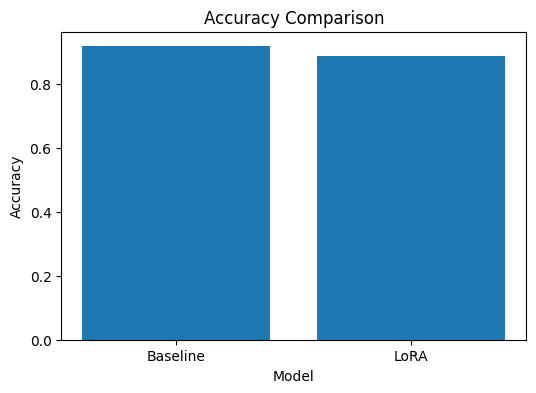

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline", "LoRA"]
accuracy = [baseline_result["eval_accuracy"], lora_result["eval_accuracy"]]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

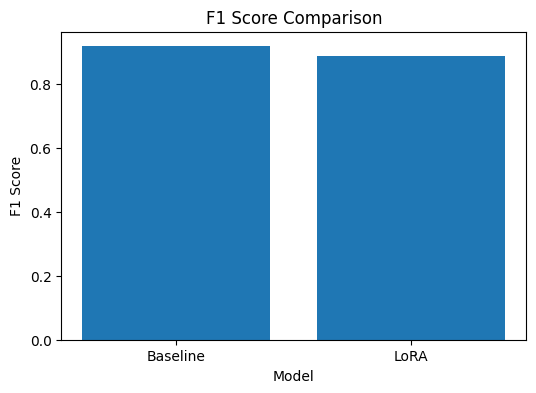

In [ ]:
f1_scores = [baseline_result["eval_f1"], lora_result["eval_f1"]]

plt.figure(figsize=(6,4))
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()

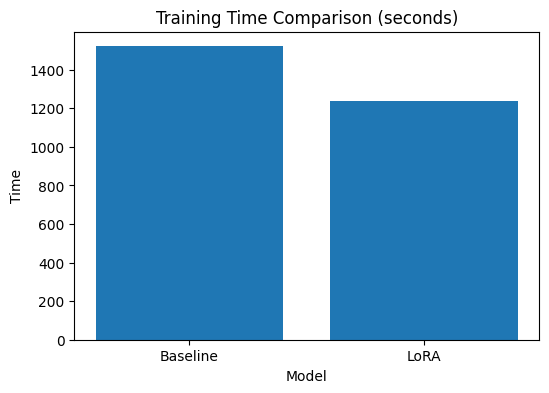

In [ ]:
times = [baseline_time, lora_time]

plt.figure(figsize=(6,4))
plt.bar(models, times)
plt.title("Training Time Comparison (seconds)")
plt.xlabel("Model")
plt.ylabel("Time")
plt.show()